The block below imports a necessary module and checks if you are in the right directory. If you do not see a list of python files when you run the block, please make sure you have uploaded the zip file and unzipped it.

In [21]:
import matplotlib.pyplot as plt

If you want to create a random knowledge base, run the following code.

Creates the files:

* randomKB.txt - A random KB generated using 10 predicates and 100 constants.
* vocab.pkl - Indexes the full set of predicates, constants and variables used by the knowledge base.

In [ ]:
!for n in 200 300 400; do mkdir -p size$n && (cd size$n && python ../kbencoder.py --generate_kb --num_rules $n --new_vocab --save_vocab); done


The following code prepares an existing knowledge base (KB) for use. To use a KB of your choosing, replace countries_kb.txt with the file name of any KB you want to use.

Creates the file:

*   vocab.pkl - Indexes the full set of predicates, constants and variables used by the knowledge base.

In [ ]:
!for n in 200 300 400; do (cd size$n && python ../kbencoder.py --kb_path randomKB.txt --vocab_from_kb --save_vocab); done

Train a neural net to convert first-order logic atoms into meaningful numeric vectors. We call these vectors "embeddings," and the learned model the embedding model. The code creates random atoms and then uses a mechanism known as triplet loss to place unifying atoms closer together.

Creates the files:

*   rKB_model.pth - Saves the learned weights for the embedding model
*   training_loss-45-106-2-50.png - A plot of the training loss after each epoch. This file's name depends on the vocabulary of your KB: the four numbers are number of predicates, number of constants, max arity of the predicates, and the embedding size used. If you changed the KB, you'll need to look up the name in your drive and update the code block that displays this file.


In [5]:
!for n in 200 300 400; do (cd size$n && python ../kbencoder.py --kb_path randomKB.txt --train_unification_model); done

Early stopping triggered-------------] 33.7% Epoch | [Epoch 169/500, Training Loss: 0.1424, Validation Loss: 0.4567]
Saved model.
Saved plot.
unification model generated
Using cuda device
Uni model embed size: 50
 [████████████████████] 3500/3500 Anchors generated                                                 
 [████████████████████] 70000/70000 Triplets generated                                              
 [█████---------------] 18422/70000 Triplet encodings                                               

IOPub data rate exceeded.
The Jupyter server will temporarily stop sending output
to the client in order to avoid crashing it.
To change this limit, set the config variable
`--ServerApp.iopub_data_rate_limit`.

Current values:
ServerApp.iopub_data_rate_limit=1000000.0 (bytes/sec)
ServerApp.rate_limit_window=3.0 (secs)



 [█████████████-------] 47992/70000 Triplet encodings                                               

IOPub data rate exceeded.
The Jupyter server will temporarily stop sending output
to the client in order to avoid crashing it.
To change this limit, set the config variable
`--ServerApp.iopub_data_rate_limit`.

Current values:
ServerApp.iopub_data_rate_limit=1000000.0 (bytes/sec)
ServerApp.rate_limit_window=3.0 (secs)



 [██████████████████--] 64219/70000 Triplet encodings                                               

...

 [████████████████████] 70000/70000 Triplet encodings                                               
Early stopping triggered-------------] 18.0% Epoch | [Epoch 91/500, Training Loss: 0.2500, Validation Loss: 0.4853]
Saved model.
Saved plot.
unification model generated
Using cuda device
Uni model embed size: 50
 [████████████████████] 3500/3500 Anchors generated                                                 
 [████████████████████] 70000/70000 Triplets generated                                              
 [█████---------------] 18275/70000 Triplet encodings                                               

IOPub data rate exceeded.
The Jupyter server will temporarily stop sending output
to the client in order to avoid crashing it.
To change this limit, set the config variable
`--ServerApp.iopub_data_rate_limit`.

Current values:
ServerApp.iopub_data_rate_limit=1000000.0 (bytes/sec)
ServerApp.rate_limit_window=3.0 (secs)



 [██████████████------] 51226/70000 Triplet encodings                                               

IOPub data rate exceeded.
The Jupyter server will temporarily stop sending output
to the client in order to avoid crashing it.
To change this limit, set the config variable
`--ServerApp.iopub_data_rate_limit`.

Current values:
ServerApp.iopub_data_rate_limit=1000000.0 (bytes/sec)
ServerApp.rate_limit_window=3.0 (secs)



 [████████████████████] 70000/70000 Triplet encodings                                               
Early stopping triggered-------------] 24.8% Epoch | [Epoch 125/500, Training Loss: 0.1694, Validation Loss: 0.4809]
Saved model.
Saved plot.
unification model generated


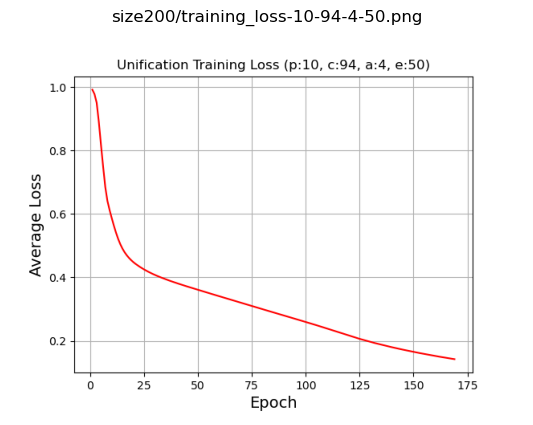

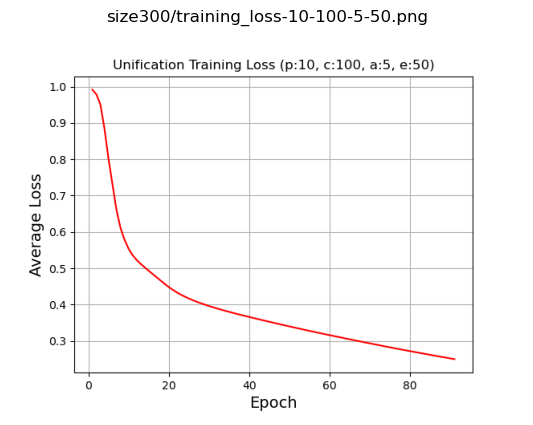

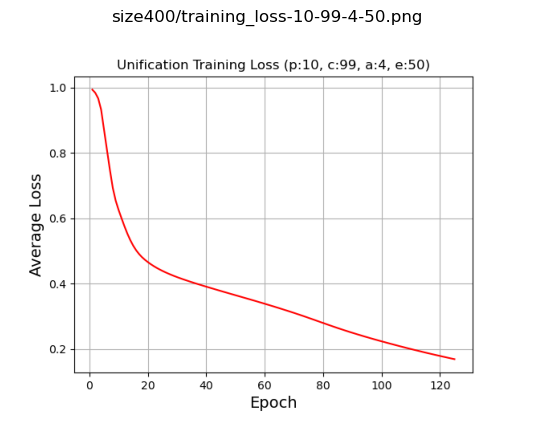

In [6]:
from pathlib import Path

for folder in sorted(p for p in Path(".").iterdir() if p.is_dir() and p.name.startswith("size")):
    images = sorted(folder.glob("training_loss*.png"))
    if not images:
        continue

    img_path = images[0]
    img = plt.imread(img_path)

    plt.figure(figsize=(8, 5))
    plt.title(str(img_path))
    plt.imshow(img)
    plt.axis("off")
    plt.show()

Generate a set of train and test queries from your knowledge base. This will also generate the deductive closure (all facts that can be inferred) of your KB using forward-chaining.

Produces the files:

*  all_facts.txt - A list of all facts that can be inferred from the KB. This is used to generate queries that are guaranteed to have an answer.
*  train_queries.txt - A set of training queries where each will have at least one answer.
*  test_queries.txt - A set of test queries where each will have at least one answer.


In [7]:
!for n in 200 300 400; do (cd size$n && python ../kbencoder.py --kb_path randomKB.txt -g); done

Generating facts list...
Forward chaining depth: 1
New facts: 93
Forward chaining depth: 2
New facts: 12
Forward chaining depth: 3
New facts: 7
Forward chaining depth: 4
New facts: 1
Forward chaining depth: 5
New facts: 1
Forward chaining depth: 6
New facts: 2
Forward chaining depth: 7
New facts: 1
Forward chaining depth: 8

Facts list generated
117 total facts. Max depth = 7

Number of queries: 200
100 training queries generated
100 testing queries generated
Generating facts list...
Forward chaining depth: 1
New facts: 54
Forward chaining depth: 2

Facts list generated
54 total facts. Max depth = 1

Number of queries: 200
100 training queries generated
100 testing queries generated
Generating facts list...
Forward chaining depth: 1
New facts: 4
Forward chaining depth: 2

Facts list generated
4 total facts. Max depth = 1

Number of queries: 200
100 training queries generated
100 testing queries generated


Create a training set for the scoring model. The examples will consist of goal, rule, score pairs, where a score of 1 means the rule can solve the goal, and 0 means it cannot. It runs the full set of training queries with a randomized backward-chaining process. This step can sometimes take a long time and is not able to take advantage of a GPU (with the countries_kb KB it took ~45 minutes).

Creates a file:
*  mr_train_examples.csv - Contains a line for each goal/rule/score example.

In [ ]:
!for n in 200 300 400; do (cd size$n && python ../kbencoder.py --kb_path randomKB.txt -p); done

running training queries...
Negative facts will be generated
1: [p5(X6, X6)]
Restart...                                                                                          
Restart...                                                                                          
Answers: 0                                                                                          

2: [p7(a40, a41, X0, a86)]
min depth: 1                                                                                        
Nodes: 2                                                                                            
Answers: 1                                                                                          

3: [p6(X8, X8)]
min depth: 2                                                                                        
Nodes: 33440                                                                                        
Answers: 20                                                           

Train the scoring model. This step will usually take several minutes, especially if you are not using a GPU (for the countries_kb KB, it takes about 30 minutes on CPU).

Creates a file:
* uni_mr_model.pt - Contains the weights for the learned scoring model

In [ ]:
!for n in 200 300 400; do (cd size$n && python ../nnreasoner.py --embed_type unification); done

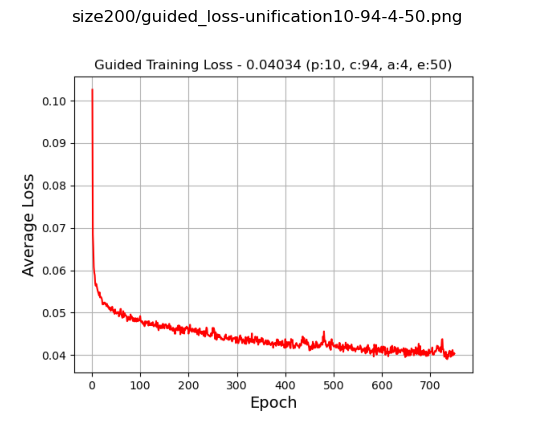

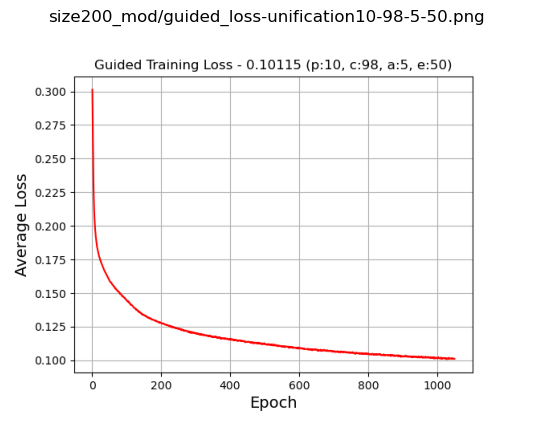

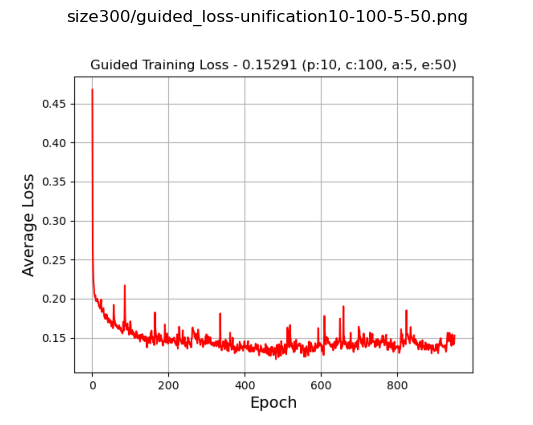

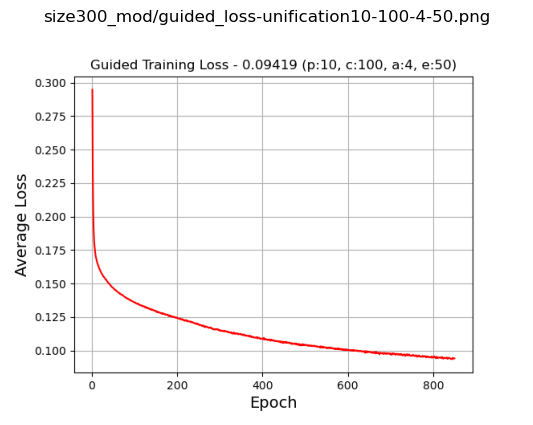

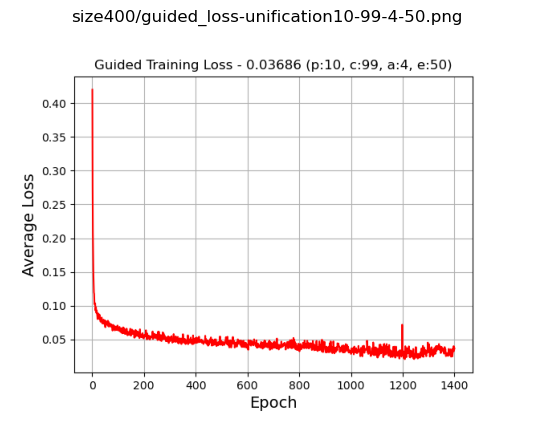

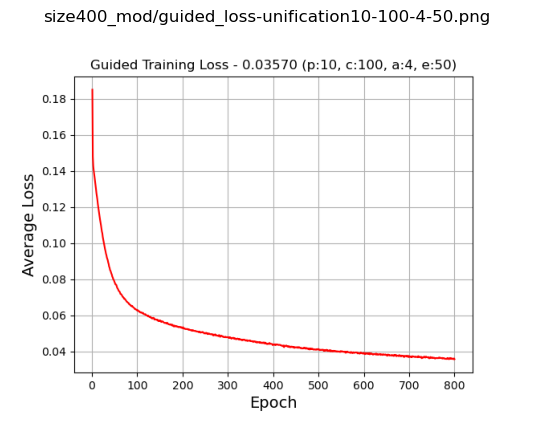

In [22]:
from pathlib import Path

for folder in sorted(p for p in Path(".").iterdir() if p.is_dir() and p.name.startswith("size")):
    images = sorted(folder.glob("guided_loss*.png"))
    if not images:
        continue

    img_path = images[0]
    img = plt.imread(img_path)

    plt.figure(figsize=(8, 5))
    plt.title(str(img_path))
    plt.imshow(img)
    plt.axis("off")
    plt.show()


Evaluate the scoring model by running evaluate.py. We compare the standard backward-chaining algorithm (-s) with the one that uses our learned scoring model (-u).

The output lists each query, and then provides a line that gives information about query execution. These are: number of nodes explored in the tree, depth of the solution, execution time in seconds, and the speed of exploring the tree (nodes per second).

The names of the files produced depend on the KB used and the options selected. The code below produces the files:

* std-45-106-2-50.csv - A CSV file with query results for the standard backward-chaining algorithm
* ming-45-106-2-50.csv - A CSV file with query results for the learned reasoner. ming stands for "min scoring goal" and is the default strategy for deciding how to make use of the scores

If you use a different knowledge base, you will likely get different file names that depend on the features of that KB's vocabulary.

In [ ]:
!for n in 200 300 400; do (cd size$n && python ../evaluate.py --kb randomKB.txt -s && python ../evaluate.py --kb randomKB.txt -u); done

The results suggest only minor improvements for the countries_kb KB: on average 3.75 vs. 4.39 node per query when I ran it. You may get different results due to the randomization of training and random selection of test queries. Larger, more complex KBs can see much larger improvements, sometimes an order of magnitude or more.

The code below shows the first 10 lines of each query result file. A given line has:
* query sequence number
* configuration name
* number of nodes explored
* depth of solution (0 if no solution found)
* did the system find a solution (true/false)
* time in seconds

You can import these files into a spreadsheet in order to create plots or summary statistics.

In [ ]:
!head std-36-759-3-50.csv
!head ming-36-759-3-50.csv